In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# **Problem Statement**

* Online discussion platforms often categorize user comments into different internal handling categories based on their content and context.

* The objective of this project is to build a machine learning model that can automatically classify comments into one of four predefined categories using both textual and structured metadata.

* This problem is framed as a multi-class classification task, where the primary challenge lies in effectively combining unstructured text data with structured numerical and categorical features.


# 1. **Importing Libraries**

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report
from lightgbm import LGBMClassifier

# 2. **Loading the Data**

In [3]:
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample shape:", sample_df.shape)

Train shape: (198000, 15)
Test shape: (102000, 14)
Sample shape: (102000, 2)


# 3. **Initial Data and Column Checks**

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


In [6]:
train_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [7]:
test_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


In [8]:
training_columns = train_df.columns.tolist()
print(f'Training Columns:{training_columns}')

Training Columns:['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']


In [9]:
testing_columns = test_df.columns.tolist()
print(f'Training Columns:{testing_columns}')

Training Columns:['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment']


## **Insights-1** 

1. **Data Dimensions:**
   * The training dataset (`train_df`) has 1,98,000 rows and 15 columns.
   * The testing dataset (`test_df`) has 1,02,000 rows and 14 columns.
      
2. **Column Consistency:**
   * The `label` column is present in `train_df` but not in `test_df` as expected (it's the target variable.)
   * All other common features, specifically `created_date`, `post_id`, `emoticon_1`, `emoticon_2`, `emoticon_3`, `upvote`, `downvote`, `if_1`, `if_2`, `race`, `religion`, `gender`, `disability`, and `comment`, are consistently named and present in both datasets without any inconsistencies in spelling or formatting.
3.  **Missing Values (Preliminary Check from `info()` outputs)**:
    *   The `race`, `religion`, and `gender` columns in both `train_df` and `test_df` have a significant number of missing values (only about 52k non-null entries out of 198k in training data, and 26k out of 102k in test data).
    *   The `comment` column in `train_df` has 1 missing value. `test_df`'s `comment` column is complete.

4.  **Data Types:**
    *   `created_date` is currently an `object` type and will need to be converted to datetime.
    *   `disability` is a `bool` type and might need to be converted to an integer for some models.
    *   `race`, `religion`, `gender`, and `comment` are `object` types, indicating they are categorical or text data.
   

## **Description of All Columns**

| Column Name    |                        Description                                                                    |
| :------------- | :----------------------------------------------------------------------------- |
| comment        | The raw text content of the comment.                                           |
| created_date   | The date and time when the comment was posted.                                 |
| post_id        | A unique identifier linking the comment to a discussion thread or parent post. |
| emoticon_1     | Indicator for the presence of symbols from the first internal emoticon group.  |
| emoticon_2     | Indicator for the presence of symbols from the second internal emoticon group. |
| emoticon_3     | Indicator for the presence of symbols from the third internal emoticon group.  |
| upvote         | Number of positive reactions received by the comment.                          |
| downvote       | Number of negative reactions received by the comment.                          |
| if_1           | Internal feature one that is hidden by the platform.                           |
| if_2           | Internal feature two that is hidden by the platform.                           |
| race           | Indicator showing whether the system detected references to a specific group identity. |
| religion       | Indicator showing whether the system detected references to a belief-related topic. |
| gender         | Indicator showing whether the system detected references to a gender-related topic. |
| disability     | Indicator showing whether the system detected references to an ability-related topic. |
| label          | The final category assigned to the comment by the platform (Target Variable). This variable can take four distinct values, each corresponding to a different internal handling category. |

# 4. **Prelimery Data Analyzing**

In [10]:
x = train_df.duplicated().sum()

if x>0:
    train_df.drop_duplicates(inplace=True)
else:
    print("No duplicates found!!")

No duplicates found!!


In [11]:
y = test_df.duplicated().sum()

if y>0:
    print(y)
else:
    print("No duplicates found!!")

No duplicates found!!


In [12]:
columns = ['post_id','emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2','race','religion','gender','disability']

for col in columns:
    print(f"\nUnique Values for column '{col}' in train_df:")
    display(train_df[col].unique())
    print(f"\nUnique Values for column '{col}' in test_df:")
    display(train_df[col].unique())
    print('-'*90)


Unique Values for column 'post_id' in train_df:


array([ 73,  39,  31,  72,  71, 120,  40, 111,  64, 123,  61, 105,  84,
       118,  76,  24,  91,  85, 102,  70,  74,  77,  66,  93, 100,  87,
        83, 103, 101, 108, 115,  79,  89,  75, 104,  90,  95,  96,  67,
       129,  82,  50,  43,  42, 109,  88, 125,  86,  20, 113,  65, 110])


Unique Values for column 'post_id' in test_df:


array([ 73,  39,  31,  72,  71, 120,  40, 111,  64, 123,  61, 105,  84,
       118,  76,  24,  91,  85, 102,  70,  74,  77,  66,  93, 100,  87,
        83, 103, 101, 108, 115,  79,  89,  75, 104,  90,  95,  96,  67,
       129,  82,  50,  43,  42, 109,  88, 125,  86,  20, 113,  65, 110])

------------------------------------------------------------------------------------------

Unique Values for column 'emoticon_1' in train_df:


...

------------------------------------------------------------------------------------------

Unique Values for column 'disability' in train_df:


array([False,  True])


Unique Values for column 'disability' in test_df:


array([False,  True])

------------------------------------------------------------------------------------------


In [13]:
null_percent1 = (train_df.race.isna().sum()/train_df.shape[0])*100
print(f"Percentage of null values for race column in train_df -> {null_percent1} %")

null_percent2 = (test_df.race.isna().sum()/test_df.shape[0])*100
print(f"Percentage of null values for race column in test_df -> {null_percent2} %")

Percentage of null values for race column in train_df -> 73.4459595959596 %
Percentage of null values for race column in test_df -> 73.79313725490196 %


In [14]:
null_percent3 = (train_df.religion.isna().sum()/train_df.shape[0])*100
print(f"Percentage of null values for religion column in train_df -> {null_percent3} %")

null_percent4 = (test_df.religion.isna().sum()/test_df.shape[0])*100
print(f"Percentage of null values for religion column in test_df -> {null_percent4} %")

Percentage of null values for religion column in train_df -> 73.4459595959596 %
Percentage of null values for religion column in test_df -> 73.79313725490196 %


In [15]:
null_percent5 = (train_df.gender.isna().sum()/train_df.shape[0])*100
print(f"Percentage of null values for gender column in train_df -> {null_percent5} %")

null_percent6 = (test_df.gender.isna().sum()/test_df.shape[0])*100
print(f"Percentage of null values for gender column in test_df -> {null_percent6} %")

Percentage of null values for gender column in train_df -> 73.4459595959596 %
Percentage of null values for gender column in test_df -> 73.79313725490196 %


In [16]:
train_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [17]:
test_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2
count,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000
mean,68.359422,0.280078,0.048353,0.118902,2.609402,0.661667,1.903078,7.956206
std,27.923491,1.043353,0.257278,0.480484,4.966033,1.965536,26.273483,15.186746
min,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000
max,129.000000,95.000000,8.000000,19.000000,189.000000,95.000000,1866.000000,1798.000000


## **Insights-2**

As part of the preliminary data analysis, several integrity and consistency checks were performed on both the training and test datasets before proceeding to deeper exploration and preprocessing.

1. **Duplicate Check:**  
- No duplicate rows were found in either the training or test datasets, confirming that each record represents a unique comment instance.

2. **Uniqueness and Value Ranges:**  
- For most numerical and categorical features (such as emoticon counts, vote counts, internal features, and flags), the set of unique values in the training and test datasets is largely consistent. This indicates that both datasets follow a similar schema and distribution, reducing the risk of unexpected behavior during inference.

- A notable observation is that the `post_id` feature contains only a limited number of unique values (53 in training and 45 in test), despite the large number of rows. This suggests that `post_id` represents discussion threads or parent posts, with multiple comments associated with each thread, rather than serving as a row-level identifier.

3. **Categorical Feature Consistency:**  
- The categorical attributes related to race, religion, and gender exhibit identical category sets across training and test datasets, apart from ordering. This confirms that no unseen categories appear in the test data, which simplifies encoding and ensures compatibility during prediction.

4. **Missing Value Patterns:**  
- A high proportion of missing values (approximately 73–74%) is observed in the race, religion, and gender columns for both training and test datasets. The near-identical missingness percentages across datasets suggest that these missing values are systematic and likely represent the absence of detected references rather than data quality issues.

5. **Numerical Feature Distribution:**  
- Summary statistics from `describe()` show that engagement-related features such as upvotes, downvotes, and internal scores are highly skewed, with a majority of values concentrated near zero and a small number of extreme outliers. Importantly, the mean, median, and spread of these features are very similar between training and test datasets, indicating no major distribution shift.

- Overall, these checks confirm that the datasets are clean, structurally consistent, and well-aligned between training and test splits. The observations from this stage inform later preprocessing decisions, particularly for handling skewed numerical features and categorical attributes with high missingness.


# 5. **Exploratory Data Analysis(EDA)**

### Distribution of Engagement and Internal Features in Train Dataset

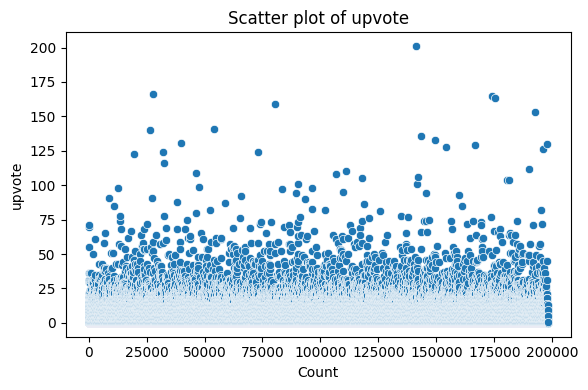

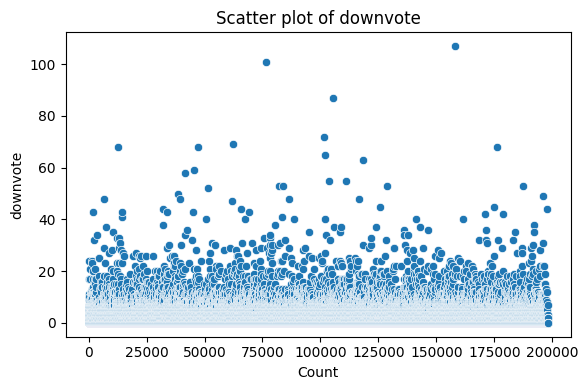

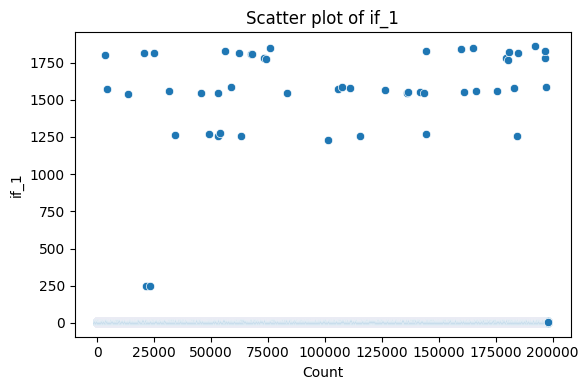

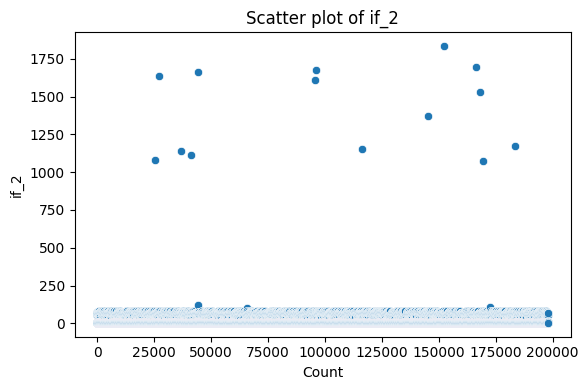

In [18]:
cols = ['upvote', 'downvote', 'if_1', 'if_2']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(train_df[col])
    plt.xlabel("Count")
    plt.ylabel(f"{col}")
    plt.title(f'Scatter plot of {col}')
    plt.tight_layout()
    plt.show()

Insights:

* The engagement features (upvote and downvote) are highly right-skewed, with most comments receiving very low reaction counts and a small number showing extremely high values. Similarly, the internal scoring features (if_1 and if_2) contain strong outliers with most observations clustered near zero.

* These patterns indicate heavy imbalance in feature distributions and suggest that transformation techniques such as log scaling may help reduce the influence of extreme values during model training.

### Distribution of Engagement and Internal Features in Test Dataset

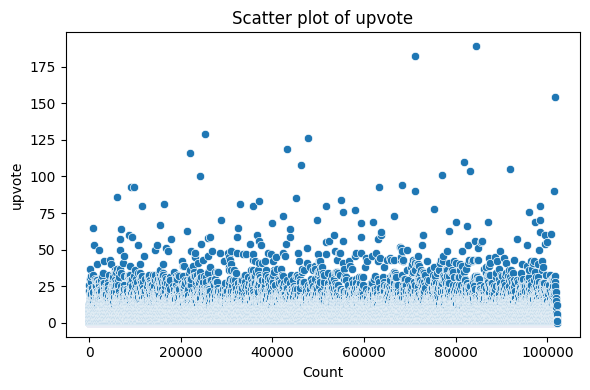

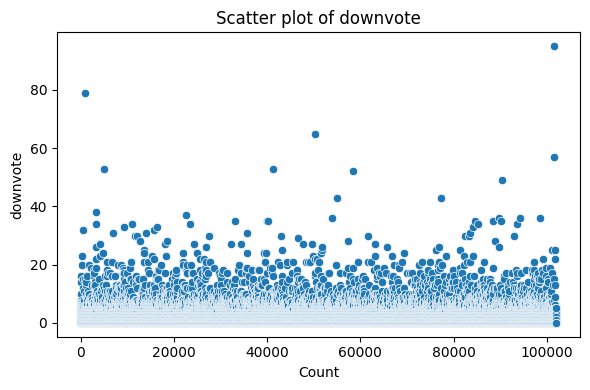

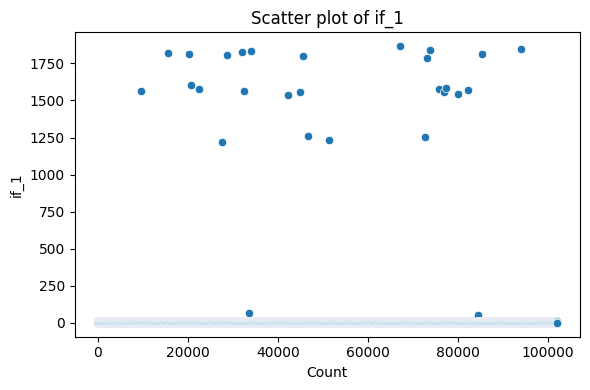

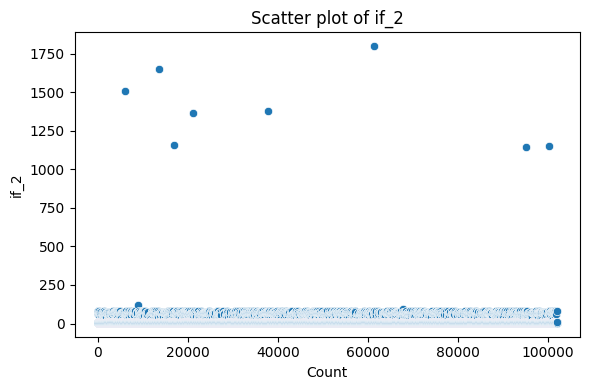

In [19]:
cols = ['upvote', 'downvote', 'if_1', 'if_2']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(test_df[col])
    plt.xlabel("Count")
    plt.ylabel(f"{col}")
    plt.title(f'Scatter plot of {col}')
    plt.tight_layout()
    plt.show()

Insights:

* The engagement features (upvote and downvote) in the test dataset show the same right-skewed pattern observed in the training data, where most comments receive very low reaction counts and only a small number show high values. The internal platform features (if_1 and if_2) also exhibit similar clustering near lower values with occasional extreme outliers.

* This consistency between training and test distributions suggests that the model is unlikely to face distribution mismatch, and the same preprocessing strategies can be safely applied to both datasets.

### Missing Value Distribution in Train Dataset

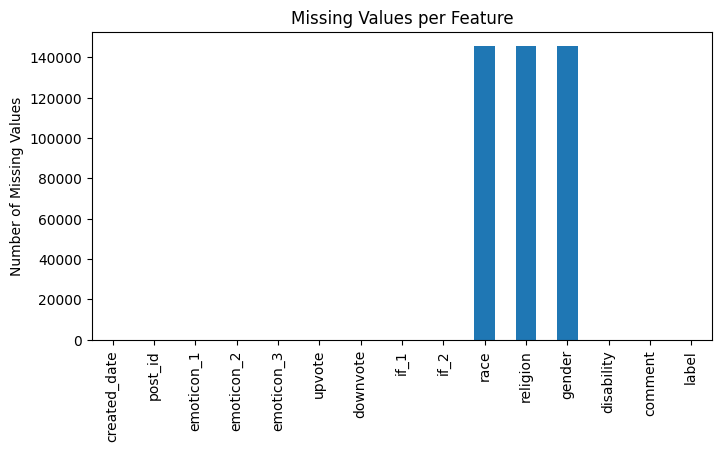

In [20]:
missing = train_df.isna().sum()

plt.figure(figsize=(8,4))
missing.plot(kind="bar")
plt.title("Missing Values per Feature")
plt.ylabel("Number of Missing Values")
plt.show()

Insights:

* Missing values are concentrated in the race, religion, and gender columns, each containing a very high proportion of null entries. Other features, including the comment text, do not contain missing values.

* The consistent missing pattern across identity-related attributes suggests that missing values likely represent absence of detected references rather than data corruption. Therefore, these missing values can be handled using category-based imputation rather than row removal.

### Missing Value Distribution in Test Dataset

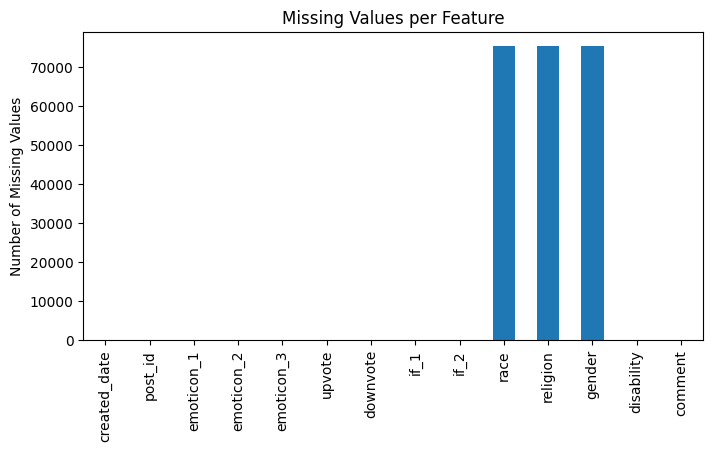

In [21]:
missing = test_df.isna().sum()

plt.figure(figsize=(8,4))
missing.plot(kind="bar")
plt.title("Missing Values per Feature")
plt.ylabel("Number of Missing Values")
plt.show()

Insights:

* The test dataset shows missing values only in the race, religion, and gender columns, following the same pattern observed in the training dataset. The proportion of missing values is also nearly identical across both datasets.

* This consistency indicates that missingness is systematic and confirms that the same imputation strategy used for the training data can be safely applied to the test dataset.

### Correlation Analysis of Numerical Features in Train Dataset

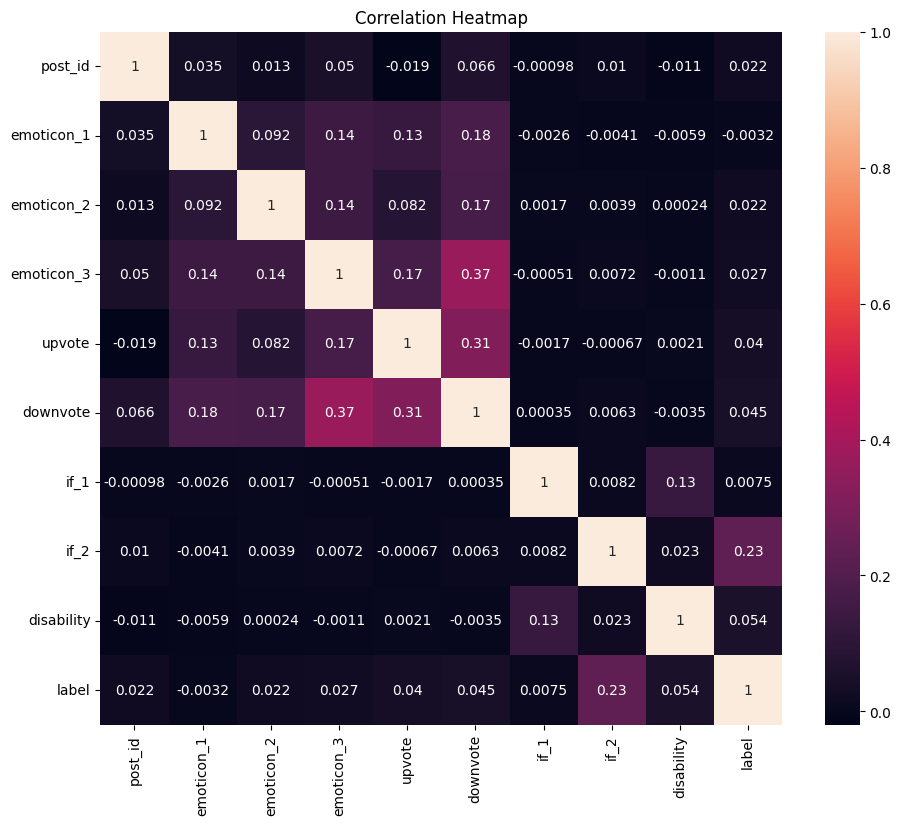

In [22]:
corr = train_df.corr(numeric_only=True)

plt.figure(figsize=(11,9))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

Insights:

* Most numerical features show very weak correlation with the target label, indicating that no single feature strongly drives the prediction. The internal feature `if_2` shows the highest positive correlation with the label, suggesting it may carry useful predictive information.

* Moderate correlation is observed between engagement metrics (upvote and downvote), which is expected as higher engagement can include both positive and negative reactions. Overall, no severe multicollinearity is observed among features.

### Correlation Analysis of Numerical Features in Test Dataset

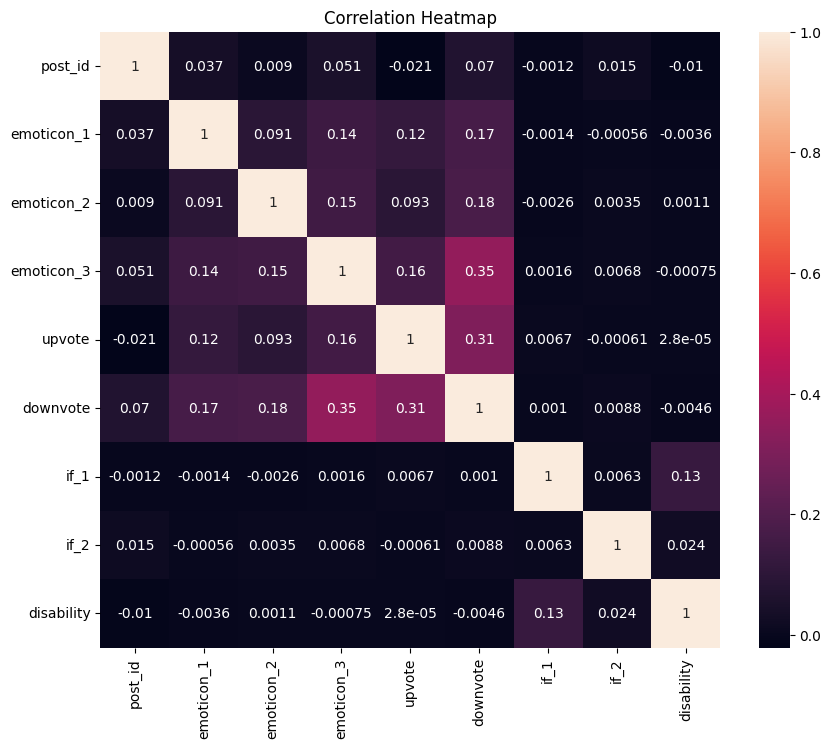

In [23]:
corr = test_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

Insights:

* The correlation structure in the test dataset closely mirrors the training dataset. Engagement features such as upvote and downvote show moderate positive correlation, while most other features have weak relationships with each other.

* No strong multicollinearity is observed. The similarity between train and test correlation patterns confirms structural consistency across datasets.

### Distribution of Numerical Features and Target Variable

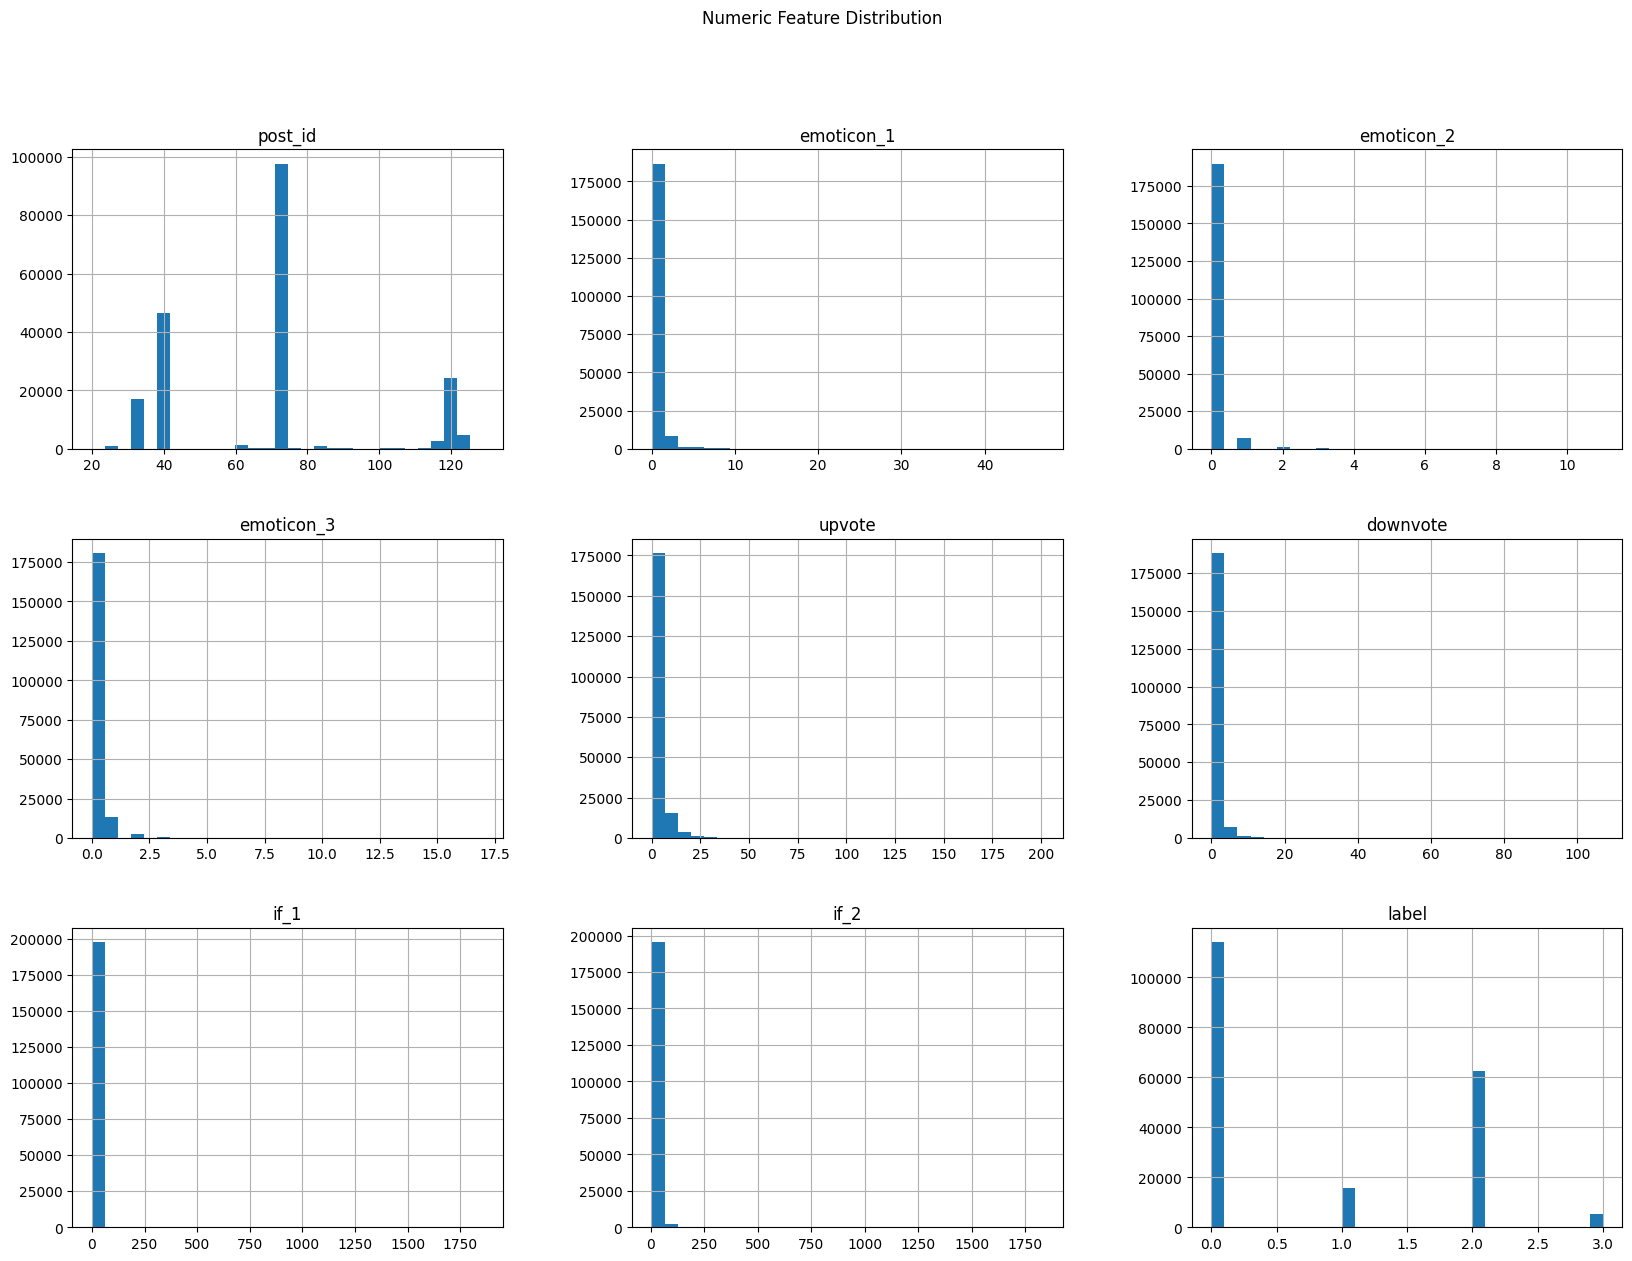

In [24]:
num_cols = train_df.select_dtypes(include=int).columns.tolist()

train_df[num_cols].hist(figsize=(20,14), bins=30)
plt.suptitle("Numeric Feature Distribution")
plt.show()

Insights:

* Most numerical features such as emoticon counts, upvote, downvote, and internal features are heavily right-skewed, with the majority of values concentrated near zero and a small number of extreme outliers.

* The internal features (if_1 and if_2) show strong clustering at low values with rare large spikes. The target variable (label) is clearly imbalanced, with class 0 dominating the dataset and class 3 having the fewest samples.

### Distribution of Numerical Features in Test Dataset

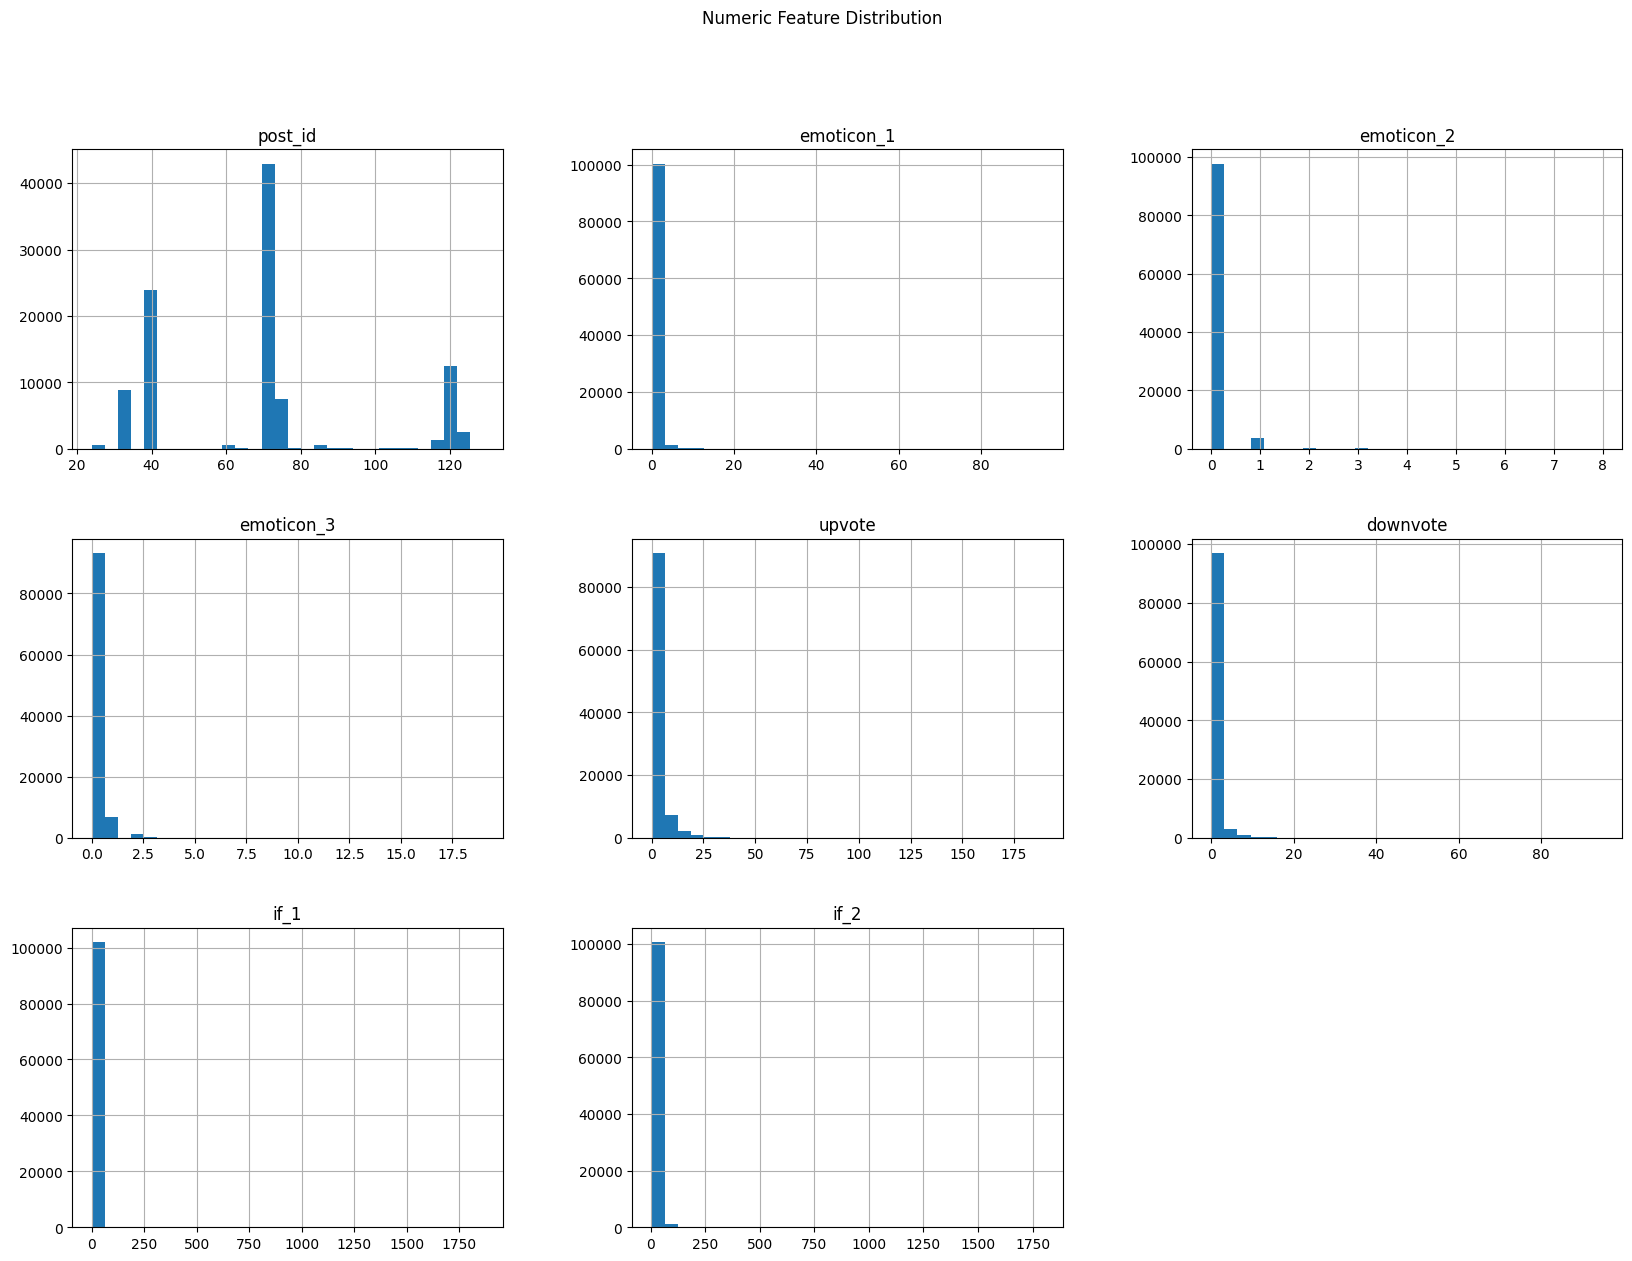

In [25]:
num_cols = test_df.select_dtypes(include=int).columns.tolist()

test_df[num_cols].hist(figsize=(20,14), bins=30)
plt.suptitle("Numeric Feature Distribution")
plt.show()

Insights:

* The numerical features in the test dataset follow distribution patterns very similar to the training dataset, indicating good consistency between both datasets. Most variables remain highly right-skewed with values concentrated near lower ranges and occasional extreme outliers.

* Internal features (if_1 and if_2) again show strong clustering at small values with few large spikes. This similarity suggests that the model trained on training data is likely to generalize well to the test data.


### Race Feature Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

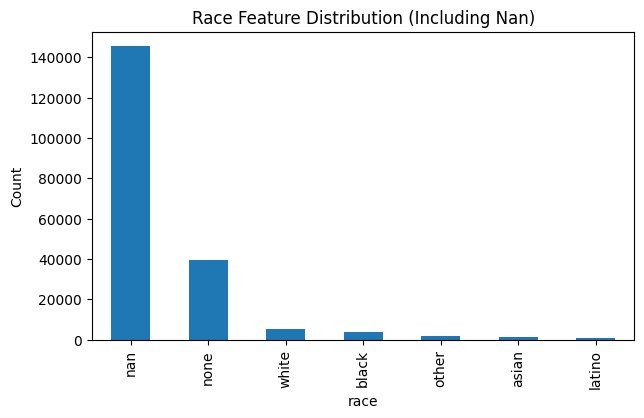

In [26]:
train_df['race'].value_counts(dropna=False).plot(kind='bar', figsize=(7,4))
plt.ylabel('Count')
plt.title('Race Feature Distribution (Including Nan)')
plt.show

Insights:

* The race feature contains a very high number of missing values, making it a sparse attribute. Among available values, "none" appears most frequently, while specific race categories such as white, black, asian, latino, and other have relatively small representation.

* The dominance of missing values suggests this feature may have limited predictive strength unless handled carefully during preprocessing.

### Religion Feature Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

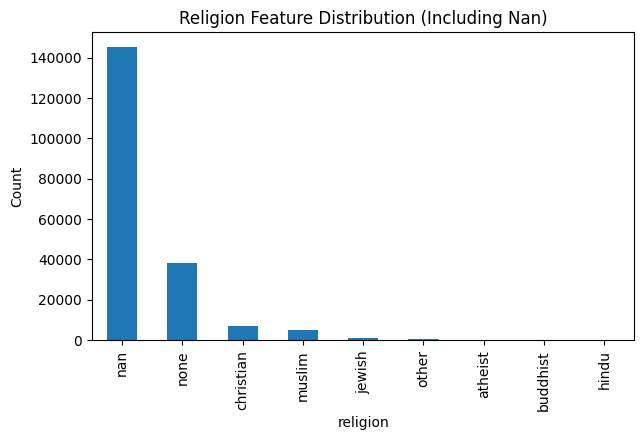

In [27]:
train_df['religion'].value_counts(dropna=False).plot(kind='bar', figsize=(7,4))
plt.ylabel('Count')
plt.title('Religion Feature Distribution (Including Nan)')
plt.show

Insights:

* The religion feature also contains a large proportion of missing values, similar to the race feature. Among the available entries, "none" is the most common category, followed by christian and muslim, while other religions have very low representation.

* The heavy imbalance and high missing percentage indicate that careful encoding or grouping may be required to avoid introducing noise into the model.

### Gender Feature Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

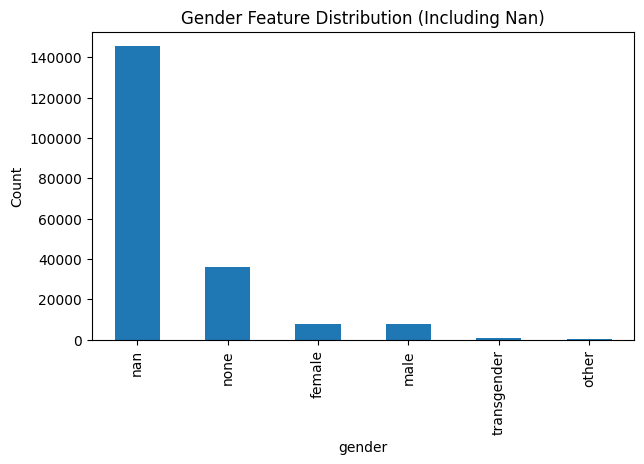

In [28]:
train_df['gender'].value_counts(dropna=False).plot(kind='bar', figsize=(7,4))
plt.ylabel('Count')
plt.title('Gender Feature Distribution (Including Nan)')
plt.show

Insights:

* The gender feature shows a high proportion of missing values, similar to race and religion. Among the available values, "none" is the most frequent category, followed by male and female, while transgender and other categories have very low representation.

* This strong imbalance and large missing proportion suggest that this feature may provide limited predictive power unless handled carefully during preprocessing.


### Distribution of Comments Across Post IDs

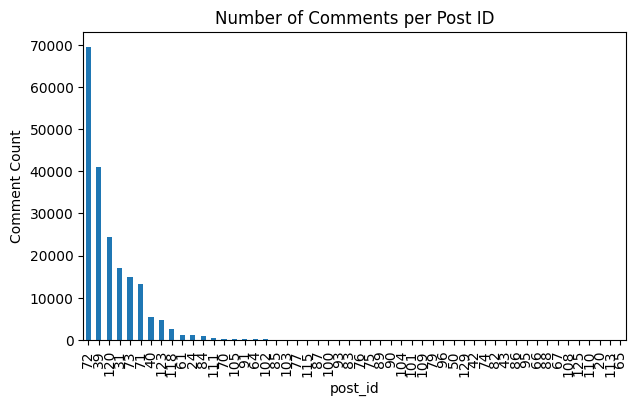

In [29]:
post_counts = train_df['post_id'].value_counts()

plt.figure(figsize=(7,4))
post_counts.plot(kind='bar')
plt.ylabel('Comment Count')
plt.title('Number of Comments per Post ID')
plt.show()

Insights:

* The number of comments is unevenly distributed across post IDs. A few posts contain a very large number of comments, while most posts have relatively fewer comments. This suggests post_id may capture contextual discussion patterns and could influence model predictions.


### Comment Length Distribution

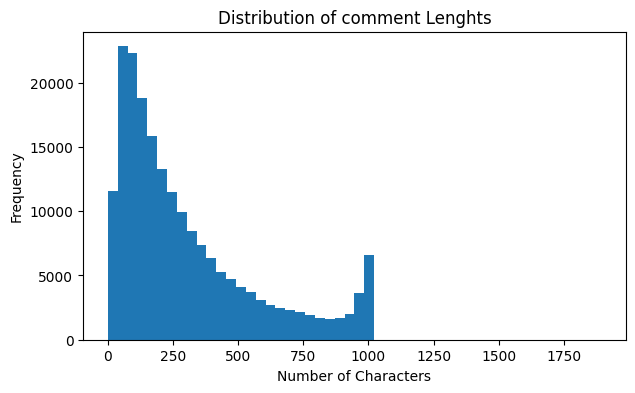

count    198000.000000
mean        302.909379
std         266.441732
min           1.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment_length, dtype: float64

In [30]:
train_df['comment_length'] = train_df['comment'].astype(str).apply(len)

plt.figure(figsize=(7,4))
plt.hist(train_df['comment_length'], bins=50)
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.title('Distribution of comment Lenghts')
plt.show()

train_df['comment_length'].describe()

Insights:

* The comment length distribution is right-skewed, with most comments being relatively short. The median comment length is around 211 characters, while a few comments are significantly longer, reaching up to approximately 1900 characters. This indicates that comment length could be a useful feature for capturing engagement or expression intensity, but extreme long comments may act as outliers.


### Comment Length vs Target Label Relationship

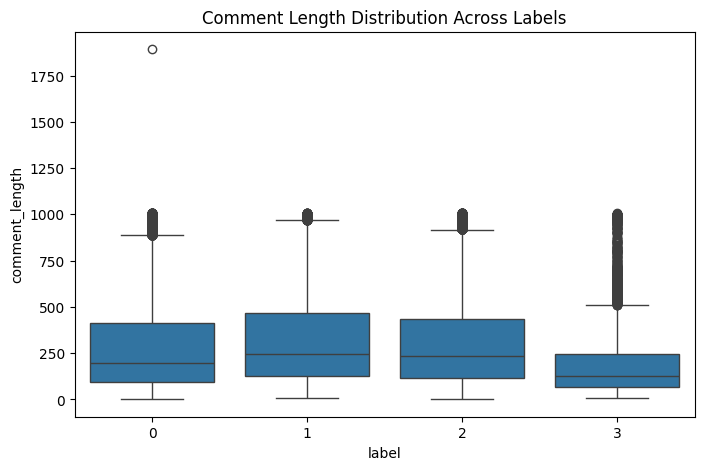

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='comment_length',data=train_df)
plt.title('Comment Length Distribution Across Labels')
plt.show()

Insights:

* Comment length varies slightly across labels. Labels 1 and 2 generally have longer comments compared to labels 0 and 3. Label 3 shows the shortest median comment length and higher variability with several long outliers.

* This suggests comment length may have some predictive signal but is not a strong standalone separator between classes.

### Average Upvotes Across Target Labels

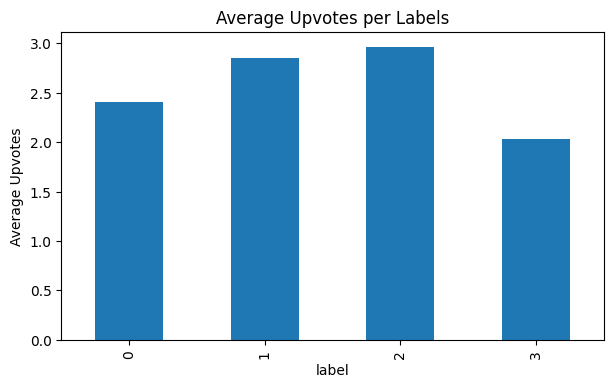

In [32]:
upvote_label_mean = train_df.groupby('label')['upvote'].mean()

plt.figure(figsize=(7,4))
upvote_label_mean.plot(kind='bar')
plt.ylabel('Average Upvotes')
plt.title('Average Upvotes per Labels')
plt.show()

Insights:

* Average upvotes differ slightly across labels. Label 2 has the highest average upvotes, followed by label 1 and label 0, while label 3 has the lowest. This indicates that comments belonging to label 2 tend to receive relatively more positive engagement, suggesting upvote count may contribute modestly to classification.

### Average Downvotes Across Target Labels

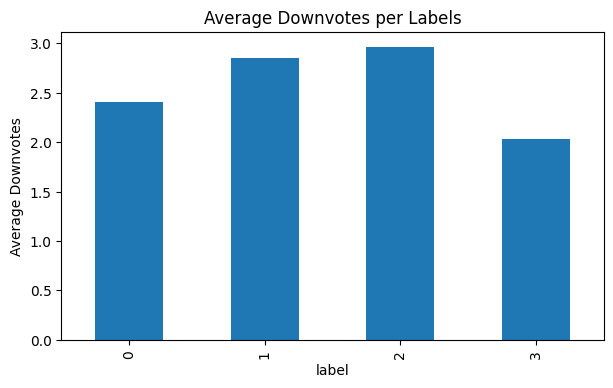

In [33]:
downvote_label_mean = train_df.groupby('label')['downvote'].mean()

plt.figure(figsize=(7,4))
upvote_label_mean.plot(kind='bar')
plt.ylabel('Average Downvotes')
plt.title('Average Downvotes per Labels')
plt.show()

Insights:

* Average downvotes are slightly higher for labels 1 and 2 compared to labels 0 and 3. Label 3 receives the lowest average downvotes. The variation is small, indicating downvote count provides limited but potentially useful signal for classification.


### Proportion of Race References Across Target Labels

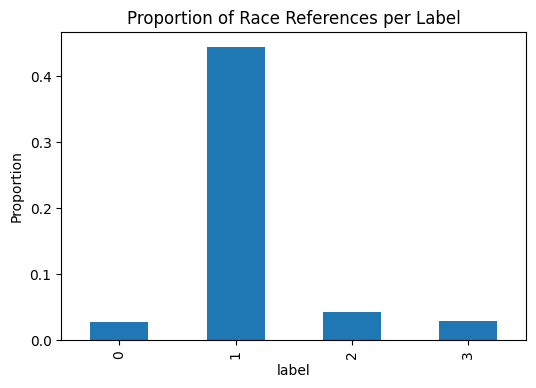

In [34]:
race_prop = ((train_df["race"] != "none") & (train_df["race"].notna())).groupby(train_df["label"]).mean()

plt.figure(figsize=(6,4))
race_prop.plot(kind="bar")
plt.ylabel("Proportion")
plt.title("Proportion of Race References per Label")
plt.show()

### Proportion of Religion References Across Target Labels

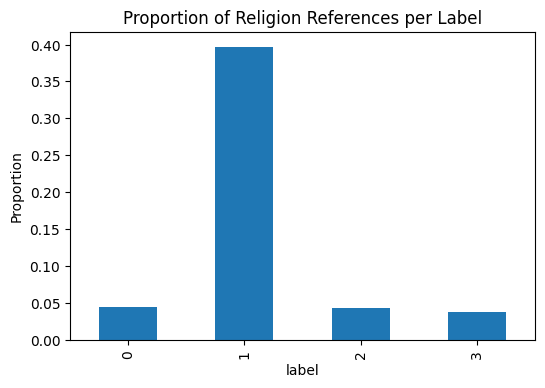

In [35]:
religion_prop = ((train_df["religion"] != "none") & (train_df["religion"].notna())).groupby(train_df["label"]).mean()

plt.figure(figsize=(6,4))
religion_prop.plot(kind="bar")
plt.ylabel("Proportion")
plt.title("Proportion of Religion References per Label")
plt.show()

### Proportion of Gender References Across Target Labels

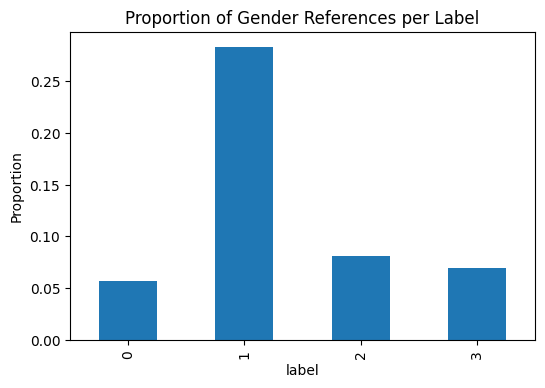

In [36]:
gender_prop = ((train_df["gender"] != "none") & (train_df["gender"].notna())).groupby(train_df["label"]).mean()

plt.figure(figsize=(6,4))
gender_prop.plot(kind="bar")
plt.ylabel("Proportion")
plt.title("Proportion of Gender References per Label")
plt.show()

### Proportion of Disability References Across Target Labels

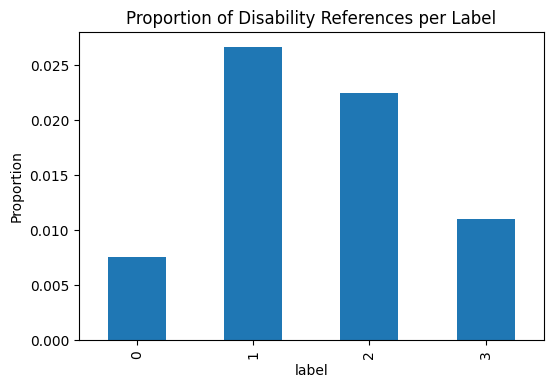

In [37]:
disability_prop = train_df.groupby('label')['disability'].mean()

plt.figure(figsize=(6,4))
disability_prop.plot(kind='bar')
plt.ylabel('Proportion')
plt.title('Proportion of Disability References per Label')
plt.show()

Combined Insight from Identity Reference Features

- From the above analysis, references to identity-related categories such as **race, religion, gender, and disability** appear more frequently in comments belonging to **label 1** compared to other labels. In contrast, labels **0, 2, and 3** generally contain much lower proportions of these references. 

- This pattern suggests that comments mentioning identity attributes tend to be more associated with specific label categories. Although these references occur in a relatively small portion of the dataset, they may still provide useful contextual signals that help the model distinguish between different classes.

### Target Variable Distribution

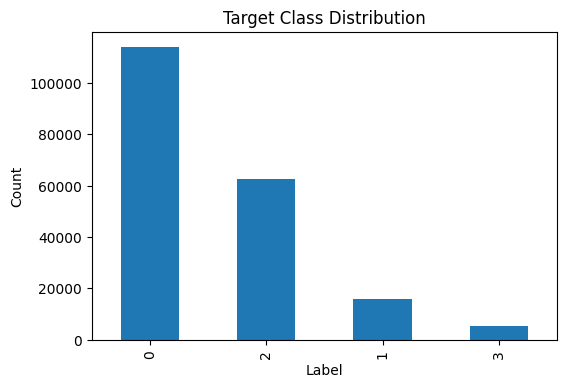

label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: count, dtype: float64

In [38]:
label_counts = train_df['label'].value_counts()

plt.figure(figsize=(6,4))
label_counts.plot(kind='bar')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Target Class Distribution')
plt.show()

(label_counts/label_counts.sum())*100

Insights:

* The target variable is highly imbalanced. Label 0 dominates the dataset, followed by label 2, while labels 1 and especially label 3 have significantly fewer samples. This imbalance may bias models toward predicting majority classes more frequently.

* Special handling techniques such as class weighting, resampling, or performance evaluation using macro metrics may be required.

# 6. **Data Pre-Processing**

In [39]:
test_df["comment_length"]  = test_df["comment"].astype(str).apply(len)

In [40]:
train_df["created_date"] = pd.to_datetime(train_df["created_date"], errors="coerce")
test_df["created_date"]  = pd.to_datetime(test_df["created_date"], errors="coerce")

for df in [train_df, test_df]:
    df["year"]  = df["created_date"].dt.year
    df["month"] = df["created_date"].dt.month
    df["day"]   = df["created_date"].dt.day

train_df.drop(columns=["created_date"], inplace=True)
test_df.drop(columns=["created_date"], inplace=True)

In [41]:
train_df["disability"] = train_df["disability"].astype(int)
test_df["disability"]  = test_df["disability"].astype(int)

In [42]:
train_df["comment"] = train_df["comment"].fillna("")

cat_cols = ["race", "religion", "gender"]

si = SimpleImputer(strategy='constant', fill_value='missing')

train_df[cat_cols] = si.fit_transform(train_df[cat_cols])
test_df[cat_cols] = si.transform(test_df[cat_cols])

print(train_df.isna().sum().sum())
print(test_df.isna().sum().sum())

0
0


In [43]:
def process_urls(text):
    url_pattern = r'(http[s]?://\S+|www\.\S+)'
    return re.sub(url_pattern, ' <URL> ', text)

train_df["having_url"] = train_df["comment"].apply(
    lambda x: 1 if re.search(r'(http[s]?://|www\.)', x) else 0
)
test_df["having_url"] = test_df["comment"].apply(
    lambda x: 1 if re.search(r'(http[s]?://|www\.)', x) else 0
)

train_df["comment"] = train_df["comment"].apply(process_urls)
test_df["comment"]  = test_df["comment"].apply(process_urls)

In [44]:
y = train_df["label"]
X = train_df.drop(columns=["label"])
X_test = test_df.copy()

In [45]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
text_col = "comment"
cat_cols = ["race", "religion", "gender"]
num_cols = [col for col in X_train_raw.columns if col not in cat_cols + [text_col]]

X_train_text = X_train_raw[text_col]
X_val_text   = X_val_raw[text_col]
X_test_text  = X_test[text_col]

X_train_num = X_train_raw[num_cols]
X_val_num   = X_val_raw[num_cols]
X_test_num  = X_test[num_cols]

X_train_cat = X_train_raw[cat_cols]
X_val_cat   = X_val_raw[cat_cols]
X_test_cat  = X_test[cat_cols]

In [47]:
ohe = OneHotEncoder(handle_unknown="ignore")

X_train_cat_encoded = ohe.fit_transform(X_train_cat)
X_val_cat_encoded   = ohe.transform(X_val_cat)
X_test_cat_encoded  = ohe.transform(X_test_cat)

In [48]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=5,
    stop_words="english"
)

X_train_text_tfidf = tfidf.fit_transform(X_train_text)
X_val_text_tfidf   = tfidf.transform(X_val_text)
X_test_text_tfidf  = tfidf.transform(X_test_text)

In [49]:
scaler = RobustScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_val_num_scaled   = scaler.transform(X_val_num)
X_test_num_scaled  = scaler.transform(X_test_num)

In [50]:
X_train_final = hstack([
    X_train_text_tfidf,
    X_train_num_scaled,
    X_train_cat_encoded
])

X_val_final = hstack([
    X_val_text_tfidf,
    X_val_num_scaled,
    X_val_cat_encoded
])

X_test_final = hstack([
    X_test_text_tfidf,
    X_test_num_scaled,
    X_test_cat_encoded
])

print("Train shape:", X_train_final.shape)
print("Validation shape:", X_val_final.shape)
print("Test shape:", X_test_final.shape)

Train shape: (158400, 30036)
Validation shape: (39600, 30036)
Test shape: (102000, 30036)


## **What all have done here**

In this stage, several preprocessing and feature engineering steps were done to prepare the dataset for model training.

- First, basic feature engineering was performed. The `comment_length` feature for the training dataset had already been created earlier during the Exploratory Data Analysis stage while analyzing the distribution of comment lengths. Therefore, in this step the same feature was generated only for the test dataset to maintain consistency between both datasets. 

- The `created_date` column was then converted to a proper datetime format, and additional temporal features such as `year`, `month`, and `day` were extracted from it. These features help capture potential temporal patterns in comment activity. After extracting these components, the original `created_date` column was removed since the derived features already contained the useful information. Additionally, the `disability` column was converted into an integer type to make it suitable for numerical processing.

- Next, missing values were handled carefully. Missing entries in the `comment` column were replaced with empty strings to ensure smooth text processing during vectorization. For categorical features (`race`, `religion`, and `gender`), missing values were imputed with the category `"missing"` so that these observations could still be utilized during model training rather than being discarded.

- To capture links-related information within comments, URL processing was applied. A new binary feature `having_url` was created to indicate whether a comment contains a link or not. At the same time, all URLs present in the text were replaced with a placeholder token `<URL>` so that the model can recognize the presence of links without being affected by the variability of different URLs.

- After preprocessing the data, the target variable (`label`) was separated from the feature set. The dataset was then divided into training and validation subsets using a stratified train–validation split to preserve the original class distribution across both subsets.

- The dataset was then divided into text, numeric and categorical feature groups. Categorical variables (`race`, `religion`, and `gender`) were encoded using One-Hot Encoding. The encoder was fitted only on the training data and then applied to validation and test datasets to prevent data leakage.

- The comment text was converted into numerical representations using TF-IDF vectorization with unigram and bigram features, allowing the model to capture both individual words and short word combinations. Numeric features were scaled using a RobustScaler to reduce the impact of extreme values and bring features to a comparable scale.

- Finally, all feature groups — TF-IDF text features, scaled numeric features, and encoded categorical features—were combined using sparse matrix stacking to construct the final feature matrices used for training, validation, and testing.

# 7. **Model Building**

## LogisticRegression

In [51]:
# base_lr = LogisticRegression(max_iter=2000)

# base_lr.fit(X_train_final, y_train)

# y_pred = base_lr.predict(X_val_final)

# f1 = f1_score(y_val, y_pred, average='macro')
# acc = accuracy_score(y_val, y_pred)

# print('F1-Score:', f1)
# print('Accuracy:', acc)
# print('\nClassification Report:')
# print(classification_report(y_val, y_pred))

F1-Score: 0.7874798737322368

Accuracy: 0.9062121212121212

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22835
           1       0.79      0.74      0.76      3183
           2       0.85      0.91      0.88     12488
           3       0.76      0.44      0.55      1094

    accuracy                           0.91     39600
    macro avg      0.84      0.76      0.79     39600
    weighted avg   0.91      0.91      0.90     39600

## DecisionTreeClassifier

In [52]:
# base_dt = DecisionTreeClassifier()

# base_dt.fit(X_train_final, y_train)

# y_pred = base_dt.predict(X_val_final)

# f1 = f1_score(y_val, y_pred, average='macro')
# acc = accuracy_score(y_val, y_pred)

# print('F1-Score:', f1)
# print('Accuracy:', acc)
# print('\nClassification Report:')
# print(classification_report(y_val, y_pred))

F1-Score: 0.7201768141499623

Accuracy: 0.8649747474747475

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     22835
           1       0.66      0.68      0.67      3183
           2       0.81      0.82      0.81     12488
           3       0.48      0.44      0.46      1094

    accuracy                           0.86     39600
    macro avg      0.72      0.72      0.72     39600
    weighted avg   0.87      0.86      0.86     39600

## MLPClassifier

In [53]:
# base_mlp = MLPClassifier(max_iter=100)

# base_mlp.fit(X_train_final, y_train)


# y_pred = base_mlp.predict(X_val_final)

# f1 = f1_score(y_val, y_pred, average='macro')
# acc = accuracy_score(y_val, y_pred)

# print('F1-Score:', f1)
# print('Accuracy:', acc)
# print('\nClassification Report:')
# print(classification_report(y_val, y_pred))

F1-Score: 0.7645485399586134

Accuracy: 0.8828535353535354

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     22835
           1       0.72      0.74      0.73      3183
           2       0.83      0.86      0.85     12488
           3       0.68      0.45      0.54      1094

    accuracy                           0.88     39600
    macro avg      0.79      0.75      0.76     39600
    weighted avg   0.88      0.88      0.88     39600

## **Hyper-Parameter Tuning**

### Model Selection for Further Optimization

Among the evaluated models, Logistic Regression achieved the highest Macro F1 score while maintaining strong overall accuracy. This indicates that the model is able to handle the high-dimensional TF-IDF features effectively and provides relatively balanced performance across different classes. 

Given these results, Logistic Regression appears to be a promising candidate for further improvement. In the next step, hyperparameter tuning will be performed to optimize the model and potentially boost its performance.

In [54]:
# log_reg = LogisticRegression()

# param_grid = {
#     "C": [0.1, 0.5, 1, 2, 5],
#     "solver": ["lbfgs", "saga"],
#     "penalty": ["l2"],
#     "max_iter": [8000]
# }

# grid_lr = GridSearchCV(
#     estimator=log_reg,
#     param_grid=param_grid,
#     scoring="f1_macro",
#     cv=3,
#     n_jobs=-1,
#     verbose=2
# )

# grid_lr.fit(X_train_final, y_train)
# best_lr = grid_lr.best_estimator_
# y_pred = best_lr.predict(X_val_final)

# print("Best Parameters:", grid_lr.best_params_)

# f1 = f1_score(y_val, y_pred, average="macro")
# acc = accuracy_score(y_val, y_pred)

# print("\nTuned Logistic Regression Results")
# print("F1-Score:", f1)
# print("Accuracy:", acc)
# print("\nClassification Report:")
# print(classification_report(y_val, y_pred))

Best Parameters: {'C': 1, 'max_iter': 8000, 'penalty': 'l2', 'solver': 'lbfgs'}

Tuned Logistic Regression Results

F1-Score: 0.7880237514333325

Accuracy: 0.9012626262626262

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     22835
           1       0.78      0.74      0.76      3183
           2       0.86      0.90      0.88     12488
           3       0.73      0.47      0.57      1094

    accuracy                           0.90     39600
    macro avg      0.83      0.76      0.79     39600
    weighted avg   0.90      0.90      0.90     39600

## **Ensemble Approach: Voting Classifier**

After hyperparameter tuning, Logistic Regression showed only a marginal improvement in performance. Although it remained the best-performing individual model, the gain from tuning alone was limited. To further improve predictive performance, an ensemble strategy was explored.

- In this step, a **soft voting ensemble** was implemented by combining **Logistic Regression and MLPClassifier**. The idea behind this approach is that different models capture different patterns in the data. Logistic Regression performs very well with high-dimensional sparse TF-IDF features and learns strong linear relationships between words and target classes. However, it may struggle to capture more complex non-linear interactions between features.

- To complement this, an **MLPClassifier (Neural Network)** was included in the ensemble because neural networks are capable of learning non-linear feature interactions that linear models may miss. By combining the probability outputs of both models using soft voting, the ensemble can leverage the strengths of each model and potentially produce more robust predictions.

- Therefore, a **Logistic Regression + MLP soft voting ensemble** was implemented in the next step to attempt further performance improvement.

In [55]:
log_reg = LogisticRegression( C=1, solver='lbfgs', max_iter=5000,
                               class_weight='balanced', n_jobs=-1 )

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate="adaptive",
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42 )

lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    n_estimators=1800,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=25,
    subsample=0.85,
    colsample_bytree=0.7,
    reg_alpha=0.15,
    reg_lambda=0.25,
    force_col_wise=True,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

voting_model = VotingClassifier(
    estimators=[
        ("lr", log_reg),
        ("mlp", mlp),
        ("lgbm", lgbm)
    ],
    voting="soft",    
    weights=[0.3, 0.2, 0.5],     #[0.6, 0.4] [0.5, 0.5] 
    n_jobs=-1 
)


voting_model.fit(X_train_final, y_train)
y_pred = voting_model.predict(X_val_final)

acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average="macro")

print("Voting Classifier Results")
print("Accuracy:", round(acc,4))
print("F1 Macro:", round(f1,4))
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


Voting Classifier Results
Accuracy: 0.9144
F1 Macro: 0.8225

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.74      0.83      0.78      3183
           2       0.88      0.90      0.89     12488
           3       0.63      0.69      0.66      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.84      0.82     39600
weighted avg       0.92      0.91      0.92     39600



Voting Classifier Results

Accuracy: 0.9087

F1 Macro: 0.8087

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.75      0.79      0.77      3183
           2       0.85      0.91      0.88     12488
           3       0.64      0.62      0.63      1094

    accuracy                           0.91     39600
    macro avg      0.81      0.81      0.81     39600
    weighted avg   0.91      0.91      0.91     39600

# 8. **Comparison Table**

### Model Performance Comparison

| Model | Macro F1 Score | Accuracy |
|------|---------------|----------|
| Logistic Regression | 0.7875 | 0.9062 |
| Decision Tree Classifier | 0.7202 | 0.8650 |
| MLP Classifier | 0.7645 | 0.8829 |
| Tuned Logistic Regression | 0.7880 | 0.9013 |
| Voting Classifier (Logistic + MLP) | 0.8087 | 0.9087 |

### Observations

All evaluated models produced competitive results on the dataset, with most models achieving accuracy close to **0.90**. The baseline Logistic Regression model demonstrated strong performance, achieving the highest accuracy among the individual models while maintaining a balanced Macro F1 score. This indicates that linear models work effectively with high-dimensional TF-IDF text features.

The Decision Tree Classifier, while capable of capturing non-linear relationships, showed lower performance compared to other models. Its Macro F1 score and accuracy were comparatively lower, which suggests that the model may have overfitted certain patterns while not generalizing well, especially for minority classes, as seen in the classification report. The MLP Classifier captured some non-linear relationships in the data and performed better than the Decision Tree but still slightly lower than Logistic Regression in terms of accuracy.

Hyperparameter tuning of Logistic Regression resulted in only a marginal improvement in Macro F1 score, indicating that the base model was already performing close to its optimal configuration.

To further improve performance, a **soft voting ensemble** combining Logistic Regression and MLPClassifier was implemented. The Voting Classifier achieved the best overall performance with an F1 score of **0.8087** and an accuracy of **0.9087**, outperforming the individual models. Therefore, the **Voting Classifier ensemble was selected as the final model for generating predictions and submission results.**

# 9. **Predicting on Test Dataset**

In [56]:
X_full_text = X[text_col]
X_full_num = X[num_cols]
X_full_cat = X[cat_cols]

X_full_cat_encoded = ohe.transform(X_full_cat)
X_full_text_tfidf = tfidf.transform(X_full_text)
X_full_num_scaled = scaler.transform(X_full_num)

X_full_final = hstack([
    X_full_text_tfidf,
    X_full_num_scaled,
    X_full_cat_encoded
])

print("Final Training shape:", X_full_final.shape)

Final Training shape: (198000, 30036)


In [57]:
voting_model.fit(X_full_final, y)
final_preds = voting_model.predict(X_test_final)

[LightGBM] [Info] Total Bins 866032
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 19073
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


# 10. **Final Submission**

In [58]:
sample_df.head()

,ID,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [59]:
sample_df["label"] = final_preds
sample_df.to_csv("submission.csv", index=False)

print("Submission file saved successfully")

Submission file saved successfully


# Dummy Model (Used for Registration)

In [60]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.dummy import DummyClassifier
# from sklearn.metrics import accuracy_score, f1_score


# train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
# test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
# sample_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

# X = train_df["comment"]
# y = train_df["label"]


# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# dummy = DummyClassifier(strategy="most_frequent")
# dummy.fit(X_train.values.reshape(-1, 1), y_train)


# y_val_pred = dummy.predict(X_val.values.reshape(-1, 1))
# print("Accuracy:", accuracy_score(y_val, y_val_pred))
# print("F1 Score:", f1_score(y_val, y_pred, average="macro"))


# test_preds = dummy.predict(test_df["comment"].values.reshape(-1, 1))

# submission = pd.DataFrame({
#     "ID": sample_df["ID"],
#     "label": test_preds
# })

# submission.to_csv("submission.csv", index=False)

# 11. Milestones

## 11.1 Milestone-1

In [61]:
# # Q1. What is the shape of the training dataset? -> (198000, 15)
# print(train_df.shape)

# # Q2. How many columns are present in the test dataset? -> 14
# print(test_df.shape[1])

# # Q3. How many columns in the training dataset have object data type? -> 5
# print(train_df.select_dtypes(include='object').shape[1])

# # Q4. How many numerical columns are present in the training dataset? -> 9
# print(train_df.select_dtypes(include='number').shape[1])

# # Q5. Which of the following columns is of boolean type? -> disability
# print(train_df.select_dtypes(include='bool').columns)

# # Q6. Which of the following columns have missing values? -> [race,religion,gender,comment]
# print(train_df.isna().sum())

# # Q7. How many distinct target classes are present in the dataset? -> 4
# print(train_df.label.nunique())

# # Q8. What percentage of the dataset approximately belongs to label 0? -> ~58%
# print(train_df.label.value_counts()/train_df.label.value_counts().sum()*100)

# # Q9. What is the median number of upvotes per comment? -> 1
# # Q10. Which numerical feature shows the largest maximum value? -> if_1
# # Q11. What is the minimum value of if_2? -> 3

# train_df.describe()

## 11.2 Milestone-2

In [62]:
# # Q1. In the context of text preprocessing for NLP, which condition must be checked in addition 
# #      to NaN values when assessing missingness in the comment column of train.csv?
# #    -> Presence of empty or whitespace-only strings

# # Q2. Convert the created_date column into datetime objects. 
# #     Identify the month that occurs the most number of times in the dataset 
# #     and enter the answer as a lowercase string -> 'may'
# train_df['created_date'] = pd.to_datetime(train_df['created_date'], errors='coerce')
# month = train_df['created_date'].dt.month_name().value_counts().idxmax()
# print(month)

# # Q3. Create a new feature called total_emoticons by calculating the sum of emoticon_1, 
# #     emoticon_2, and emoticon_3 for each row. What is the maximum value observed 
# #     in this new feature across the entire dataset? -> 60
# train_df['total_emoticons'] = train_df['emoticon_1'] + train_df['emoticon_2'] + train_df['emoticon_3']
# max_value = train_df['total_emoticons'].max()
# print(max_value)

# # Q4. Calculate the median character length (including spaces) of the comment 
# #     column for all entries where label is equal to 3. (Note: Treat any missing comments as empty strings).
# #      -> 128
# comments_3 = train_df[train_df['label']==3]['comment'].fillna('')
# median_len = comments_3.apply(len).median()
# print(median_len)

# # Q5. If you apply Min-Max Scaling to the upvote column to normalize it between the range [0, 1], 
# #     what would be the resulting scaled value for an observation that originally had exactly 10 upvotes?
# #     -> 0.0498
# min = train_df['upvote'].min()
# max = train_df['upvote'].max()

# scale_upvote = (10-min)/(max-min)
# print(scale_upvote)


# # Q6. What is the average word count (number of words separated by whitespace) for comments that 
# #     are assigned a label of 1? (Round your answer to 2 decimal places).
# #     -> 57.23
# comments_2 = train_df[train_df['label']==1]['comment'].fillna('')
# avg_word_count = comments_2.apply(lambda x: len(str(x).split())).mean()
# print(avg_word_count)


# # Q7. How many comments in the entire dataset contain the substring 
# #     "Trump"? The search should be case-insensitive. -> 24398
# count = train_df['comment'].astype(str).str.lower().str.contains("trump").sum()
# print(count)


# # Q8. Take the comment at the very first row (index 0).

# # - Remove all punctuation.

# # - Consider the following words as stop words and remove the same :  ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
# # How many words are left in the text after these two operations?
# #  -> 12
# import string 

# first = str(train_df.loc[0, 'comment'])
# stop_words = ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
# no_punc = ''.join([char for char in first if char not in string.punctuation])
# words = no_punc.lower().split()
# filter_words = [word for word in words if word not in stop_words]
# count = len(filter_words)
# print(count)

# # Q9. Convert all the text in comment column to lowercase and tokenizing using whitespace. 
# #     Compute the total number of unique tokens in the dataset and enter the value
# #     -> 425413
# tokens = []
# for comment in train_df['comment'].astype(str):
#     tokens.extend(comment.lower().split())

# unique_tokens = len(set(tokens))
# print(unique_tokens)


# # Q10. Apply the TfidfVectorizer to the comment column of train.csv with stop_words as "english", min_df as 5 and ngram_range as (1,2).
# #     How many TF-IDF features are generated using this configuration? 
# #     -> 132974
# from sklearn.feature_extraction.text import TfidfVectorizer

# comments = train_df['comment'].fillna('')
# vect = TfidfVectorizer(stop_words="english", min_df=5, ngram_range=(1,2))
# vect.fit_transform(comments)
# x = len(vect.get_feature_names_out())
# print(x)

## 11.3 Milestone-3

In [63]:
# # Split the train dataset using train_test_split with random_state=42 such that 80% is training data 
# # and remaining 20% is validation data. store the data as X_train, X_val, y_train, y_val. Lets say 
# # training data (X_train) has shape (a,b) where a is number of rows and b is the number of features,
# # similarly validation set (X_val) has shape (c,d) where c is the number of rows and d is the number
# # of features. what will be the value of a + c ? -> 198000
# from sklearn.model_selection import train_test_split

# X = train_df.drop("label", axis=1)
# y = train_df["label"]

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# a = X_train.shape[0]
# c = X_val.shape[0]
# print(a + c)

# # After converting created_date to a datetime object and extracting the day, month, and year for 
# # your X_train and X_val created in the first question, identify the most frequently occurring month 
# # across all years in X_train. Which month is it? -> 5(May)

# X_train["created_date"] = pd.to_datetime(X_train["created_date"])
# X_val["created_date"] = pd.to_datetime(X_val["created_date"])

# X_train["day"] = X_train["created_date"].dt.day
# X_train["month"] = X_train["created_date"].dt.month
# X_train["year"] = X_train["created_date"].dt.year

# X_val["day"] = X_val["created_date"].dt.day
# X_val["month"] = X_val["created_date"].dt.month
# X_val["year"] = X_val["created_date"].dt.year

# month = X_train["month"].mode()[0]
# print(month)

# # Impute the null values of categorical features with the value 'none'. Encode only religion', 
# # 'gender', 'race' features using one hot encoding, setting handle_unknown='ignore'. Make sure the 
# # output is a pandas dataframe. Let's say the shape of X_train after imputing is (a,b), what is the
# # value of b ? Note: make sure to transform X_val as well using one hot encoding. -> 17

# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder

# cat_cols = X_train.select_dtypes(include="object").columns
# si = SimpleImputer(strategy="constant", fill_value="none")

# X_train[cat_cols] = si.fit_transform(X_train[cat_cols])
# X_val[cat_cols] = si.transform(X_val[cat_cols])

# print(X_train.shape[1])

# ohe_cols = ["religion", "gender", "race"]
# ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# en_train = ohe.fit_transform(X_train[ohe_cols])
# en_val = ohe.transform(X_val[ohe_cols])

# encoded_train_df = pd.DataFrame(
#     en_train,
#     columns=ohe.get_feature_names_out(ohe_cols),
#     index=X_train.index
# )

# encoded_val_df = pd.DataFrame(
#     en_val,
#     columns=ohe.get_feature_names_out(ohe_cols),
#     index=X_val.index
# )

# X_train = X_train.drop(ohe_cols, axis=1)
# X_val = X_val.drop(ohe_cols, axis=1)

# X_train = pd.concat([X_train, encoded_train_df], axis=1)
# X_val = pd.concat([X_val, encoded_val_df], axis=1)

# # Apply CountVectorizer to the column comment of X_train and X_val obtained in previous questions, 
# # what is the sum of the counts for the document at index 1 (the second row) of the transformed 
# # X_train sparse matrix? Note: Please ensure to transform X_val as well -> 41
# from sklearn.feature_extraction.text import CountVectorizer

# cv = CountVectorizer()

# X_train_comment = cv.fit_transform(X_train["comment"])
# X_val_comment = cv.transform(X_val["comment"])
# print(X_train_comment[1].sum())

# # Convert 'disability' feature into integer type, with True being mapped to 1 and False mapped to 0.
# # What is the sum of all the 'disability values in X_train and X_val after the transformation? -> 2743

# X_train["disability"] = X_train["disability"].map({True:1, False:0})
# X_val["disability"] = X_val["disability"].map({True:1, False:0})

# total_sum = X_train["disability"].sum() + X_val["disability"].sum()
# print(total_sum)

# # Scale the numeric features using StandardScaler. What are the number of features seen during fit 
# # for X_train? Ensure that you drop all datetime columns first. -> 28
# from sklearn.preprocessing import StandardScaler

# X_train = X_train.drop(columns=["created_date"], errors="ignore")
# X_val = X_val.drop(columns=["created_date"], errors="ignore")

# num_cols = X_train.select_dtypes(include=["int64","float64"]).columns

# ss = StandardScaler()
# ss.fit(X_train[num_cols])
# print(ss.n_features_in_)

In [64]:
# # Preprocess the data in the following manner and train the model:

# # 0) Use the full raw data and first split it into training and validation sets so that 80% of the 
# # data forms X_train, y_train and the remaining 20% forms X_val, y_val.

# # After splitting:

# # Impute missing values by fitting the SimpleImputer on X_train. You are free to use any valid 
# # strategy for Imputation.

# # Use the fitted imputer to transform both X_train and X_val

# # Ensure that after imputation no value in X_train or X_val is negative.

# # If any negative value exists, convert it to positive using the absolute value function

# # 1) Convert the created_date feature into a datetime object and engineer three new numerical 
# #    features: day, month, and year. keep these three new features and drop the feature created_date. 
# #    Make sure to transform X_val accordingly.

# # 2) Transform the "comment" feature using TfidfVectorizer with stop_words='english'. 
# #    Make sure to transform X_val accordingly.

# # 3) Encode all the categorical features using one hot encoder with handle_unknown='ignore'. 
# #    Make sure to transform X_val accordingly.
                                                            
# # Now train a Multinomial Naive Bayes model on the preprocessed data. Use a pipeline if you need 
# # to. What is the macro F1 score obtained on the train dataset? -> 0.48159978662493275


# # Note: you may train Multinomial Naive Bayes model on the preprocessed data which has been 
# # obtained from previous questions and give the answer, both ways the answers will be accepted. 

# # If some feature is creating problem or giving error during fit, you can find a way to handle 
# # it such as (dropping it, encoding it, changing its data type etc).

# # What is the macro F1 score obtained on the validation dataset? -> 0.45819418922399024

# from sklearn.model_selection import train_test_split
# from sklearn.impute import SimpleImputer
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import f1_score
# from scipy.sparse import hstack
# import pandas as pd
# import numpy as np

# X = train_df.drop("label", axis=1)
# y = train_df["label"]

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


# si = SimpleImputer(strategy="most_frequent")

# X_train[:] = si.fit_transform(X_train)
# X_val[:] = si.transform(X_val)


# num_cols = X_train.select_dtypes(include=["int64","float64"]).columns

# X_train[num_cols] = X_train[num_cols].abs()
# X_val[num_cols] = X_val[num_cols].abs()


# X_train["created_date"] = pd.to_datetime(X_train["created_date"])
# X_val["created_date"] = pd.to_datetime(X_val["created_date"])

# X_train["day"] = X_train["created_date"].dt.day
# X_train["month"] = X_train["created_date"].dt.month
# X_train["year"] = X_train["created_date"].dt.year

# X_val["day"] = X_val["created_date"].dt.day
# X_val["month"] = X_val["created_date"].dt.month
# X_val["year"] = X_val["created_date"].dt.year

# X_train.drop("created_date", axis=1, inplace=True)
# X_val.drop("created_date", axis=1, inplace=True)


# tfidf = TfidfVectorizer(stop_words="english")

# train_text = tfidf.fit_transform(X_train["comment"])
# val_text = tfidf.transform(X_val["comment"])

# X_train.drop("comment", axis=1, inplace=True)
# X_val.drop("comment", axis=1, inplace=True)


# cat_cols = X_train.select_dtypes(include="object").columns

# ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# train_cat = ohe.fit_transform(X_train[cat_cols])
# val_cat = ohe.transform(X_val[cat_cols])

# X_train.drop(cat_cols, axis=1, inplace=True)
# X_val.drop(cat_cols, axis=1, inplace=True)

# X_train = X_train.astype(float)
# X_val = X_val.astype(float)

# X_train_final = hstack([train_text, train_cat, X_train.values])
# X_val_final = hstack([val_text, val_cat, X_val.values])


# model = MultinomialNB()
# model.fit(X_train_final, y_train)

# train_pred = model.predict(X_train_final)
# val_pred = model.predict(X_val_final)

# train_f1 = f1_score(y_train, train_pred, average="macro")
# val_f1 = f1_score(y_val, val_pred, average="macro")

# print(train_f1)
# print(val_f1)

In [65]:
# # Process the data in the following manner as given below and train the model.

# # 0) Use the full raw data and first split it into training and validation sets so that 80% of the 
# # data forms X_train, y_train and the remaining 20% forms X_val, y_val.
                                                             
# # After splitting:

# # Impute missing values by fitting the SimpleImputer on X_train. You are free to use any valid 
# # strategy for Imputation.

# # Use the fitted imputer to transform both X_train and X_val

# # Ensure that after imputation no value in X_train or X_val is negative.

# # If any negative value exists, convert it to positive using the absolute value function

# # 1) Convert the created_date feature into a datetime object and engineer three new numerical 
# # features: day, month, and year. keep these three new features and drop the feature created_date. 
# # Make sure to transform X_val accordingly.

# # 2) Create a new binary categorical column named is_weekend where Saturday and Sunday are 
# # represented as 1 and all other days as 0. 

# # 3) Apply TfidfVectorizer(stop_words='english') to the comment column. Make sure to transform 
# # X_val accordingly.

# # 4) Apply OneHotEncoder(handle_unknown='ignore') to the categorical features including newly 
# # created categorical feature is_weekend. Make sure to transform X_val accordingly.

# # After all above transformation, train MultinomialNB model.

# # After training, use the model to predict the labels for X_train and calculate the Macro F1 score.
# # What is the resulting score rounded to four decimal places? -> 0.4816

# # note: If some features are creating problem or giving error during fit, you can find a way to 
# # handle it such as (dropping it, encoding it, changing its data type etc).

# # What is the macro F1-score on validation set for the previous question's setup? -> 0.4581

# from sklearn.model_selection import train_test_split
# from sklearn.impute import SimpleImputer
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import f1_score
# from scipy.sparse import hstack
# import pandas as pd
# import numpy as np

# X = train_df.drop("label", axis=1)
# y = train_df["label"]

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


# si = SimpleImputer(strategy="most_frequent")

# X_train[:] = si.fit_transform(X_train)
# X_val[:] = si.transform(X_val)


# num_cols = X_train.select_dtypes(include=["int64","float64"]).columns

# X_train[num_cols] = X_train[num_cols].abs()
# X_val[num_cols] = X_val[num_cols].abs()


# X_train["created_date"] = pd.to_datetime(X_train["created_date"])
# X_val["created_date"] = pd.to_datetime(X_val["created_date"])

# X_train["day"] = X_train["created_date"].dt.day
# X_train["month"] = X_train["created_date"].dt.month
# X_train["year"] = X_train["created_date"].dt.year
# X_train["is_weekend"] = X_train["created_date"].dt.weekday.apply(lambda x: 1 if x>=5 else 0)

# X_val["day"] = X_val["created_date"].dt.day
# X_val["month"] = X_val["created_date"].dt.month
# X_val["year"] = X_val["created_date"].dt.year
# X_val["is_weekend"] = X_val["created_date"].dt.weekday.apply(lambda x: 1 if x>=5 else 0)

# X_train.drop("created_date", axis=1, inplace=True)
# X_val.drop("created_date", axis=1, inplace=True)


# tfidf = TfidfVectorizer(stop_words="english")

# train_text = tfidf.fit_transform(X_train["comment"])
# val_text = tfidf.transform(X_val["comment"])

# X_train.drop("comment", axis=1, inplace=True)
# X_val.drop("comment", axis=1, inplace=True)


# cat_cols = X_train.select_dtypes(include="object").columns

# ohe = OneHotEncoder(handle_unknown="ignore")

# train_cat = ohe.fit_transform(X_train[cat_cols])
# val_cat = ohe.transform(X_val[cat_cols])

# X_train.drop(cat_cols, axis=1, inplace=True)
# X_val.drop(cat_cols, axis=1, inplace=True)

# X_train = X_train.astype(float)
# X_val = X_val.astype(float)

# X_train_final = hstack([train_text, train_cat, X_train.values])
# X_val_final = hstack([val_text, val_cat, X_val.values])


# model = MultinomialNB()
# model.fit(X_train_final, y_train)

# train_pred = model.predict(X_train_final)
# val_pred = model.predict(X_val_final)

# train_f1 = f1_score(y_train, train_pred, average="macro")
# val_f1 = f1_score(y_val, val_pred, average="macro")

# print(round(train_f1,4))
# print(round(val_f1,4))